In [77]:
import pandas as pd
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


# Pfad korrekt auflösen
current_dir = Path.cwd()
data_path = current_dir.parent / 'data' / 'raw' / 'filemaker_records.json'

print(f'Suche Daten unter: {data_path}')

#Prüfen ob Datei existiert:
if not data_path.exists():
    raise FileNotFoundError(f'Datei nicht gefunden unter: {data_path}. Bitte Pfad prüfen')

Suche Daten unter: c:\Users\danie\OneDrive - Schule Seengen (1)\Apps\Dashboard\data\raw\filemaker_records.json


In [78]:

#Daten laden
with open(data_path, 'r', encoding='utf-8') as f:
    raw_json = json.load(f)

#Metadaten ausgeben (für Dokumentation)
print(f'Cache erstellt am: {raw_json.get('cached_at')}')
print(f"Anzahl Datensätze laut Header: {raw_json.get('record_count')}")

# Extrahiere die 'records' Liste für Analyse
records_list = raw_json.get('records', [])
print(f'Tatsächlich geladene Records: {len(records_list)}')

# Normalisieren der JSON-Struktur (fieldData extrahieren)
if len(records_list)==0:
    raise ValueError("Keine Datensätze im 'records'-Feld gefunden")

data_dicts = [record['fieldData'] for record in records_list]
df = pd.DataFrame(data_dicts)

# Diagnose
print('---Tatsächliche Spaltennamen in DataFrame----')
print(df.columns.tolist())

print("\n=== Erste 2 Zeilen (zum Abgleich der Schlüssel) ===")
print(df.head(2).to_string())

print("\n=== Prüfen auf 'MedienTitel' (oder ähnliche Namen) ===")
# Suche nach Spalten, die "Titel" enthalten
cols_with_titel = [col for col in df.columns if 'Titel' in str(col) or 'titel' in str(col)]
print(f"Gefundene Spalten mit 'Titel': {cols_with_titel}")

# Suche nach Spalten, die "Autor" enthalten
cols_with_autor = [col for col in df.columns if 'Autor' in str(col) or 'autor' in str(col)]
print(f"Gefundene Spalten mit 'Autor': {cols_with_autor}")



Cache erstellt am: 2026-06-16T08:09:45
Anzahl Datensätze laut Header: 93738
Tatsächlich geladene Records: 93738
---Tatsächliche Spaltennamen in DataFrame----
['Kategorie Alter', 'NR Zugang', 'MedienAutor', 'MedienTitel', 'Ausleihdatum', 'Mahnstufe', 'Rückgabedatum', 'Ausleihperson', 'Mahndatum 1', 'Mahndatum 2', 'Mahndatum 3', 'erstellt', 'geändert', 'Medienart', 'Storno', 'Verlängerung_Anz', 'zAutor_NºZugang', 'Ausleihe bis', 'Mahndatum 0', 'yLöschen', 'RG_Datum', 'RRMemoDat', 'Klasse_ID', 'Benutzergruppe', 'Zweigstelle', 'Transaktion(1)', 'Transaktion(2)', 'Benutzerkategorie', 'RRMemoText', 'Transaktionstyp(1)', 'Transaktionstyp(2)', 'Anz_Exemplare', 'Stat_Ausl_inkl_Verl']

=== Erste 2 Zeilen (zum Abgleich der Schlüssel) ===
  Kategorie Alter NR Zugang MedienAutor                  MedienTitel Ausleihdatum Mahnstufe Rückgabedatum Ausleihperson Mahndatum 1 Mahndatum 2 Mahndatum 3             erstellt             geändert     Medienart Storno Verlängerung_Anz zAutor_NºZugang Ausleihe bi

In [79]:


# --- 2. Bereinigung ---
import pandas as pd
import json
from pathlib import Path

# --- 0. Vorbereitung (Daten laden wie zuvor) ---
current_dir = Path.cwd()
data_path = current_dir.parent / 'data' / 'cache' / 'filemaker_records.json'

with open(data_path, 'r', encoding='utf-8') as f:
    raw_json = json.load(f)

records_list = raw_json.get('records', [])
df = pd.DataFrame([record['fieldData'] for record in records_list])

# Temporäre Kopie für den Vergleich erstellen
df_check = df.copy()

# Funktion zum Bereinigen (Trimmen & Standardisieren)
def clean_text(val):
    if pd.isna(val):
        return val
    s = str(val).strip()
    # Optional: Einheitliche Großschreibung für bessere Vergleichbarkeit (Title Case)
    # return s.title() 
    return s

# Ziel-Spalten für die Prüfung
target_cols = ['Benutzergruppe', 'Medienart']

print("=== 🔍 DETAILLIERTE INKONSISTENZEN-ANALYSE ===\n")

for col in target_cols:
    if col not in df_check.columns:
        continue
        
    print(f"--- Spalte: {col} ---")
    
    # 1. Ursprüngliche Werte zählen
    raw_counts = df_check[col].astype(str).str.strip().value_counts(dropna=False)
    print(f"Anzahl unique Werte (roh, aber gestrippt für Count): {raw_counts.size}")
    
    # 2. Bereinigungsschritt anwenden (nur für den Vergleich)
    # Wir erstellen eine neue Spalte '_clean'
    df_check[f'{col}_clean'] = df_check[col].apply(clean_text)
    
    # 3. Vergleich: Wo unterscheidet sich Original (gestrippt) von Bereinigt?
    # Eigentlich ist unser clean_text nur strip(). Der echte Nutzen kommt, wenn wir 
    # auch Groß-/Kleinschreibung angleichen oder Tippfehler korrigieren.
    # Lass uns annehmen, wir wollen auch Groß-/Kleinschreibung vereinheitlichen (z.B. alles Title Case).
    
    def standardize(val):
        if pd.isna(val): return val
        s = str(val).strip()
        return s.title() # Macht aus "schü" -> "Schü", aus "BELLETRISTIK" -> "Belletristik"
    
    df_check[f'{col}_std'] = df_check[col].apply(standardize)
    
    # Filtern nach Zeilen, wo sich das Original (gestrippt) vom Standardisierten unterscheidet
    # Wir vergleichen das gestrippte Original mit der standardisierten Version
    mask_diff = df_check[col].astype(str).str.strip() != df_check[f'{col}_std']
    
    diffs = df_check[mask_diff].copy()
    
    if len(diffs) > 0:
        print(f"⚠️  {len(diffs)} Datensätze weichen von der Standardisierung ab.")
        
        # Erstelle eine Übersichtstabelle der Änderungen
        # Gruppiere nach "Alter Wert" und "Neuer Wert"
        diffs['Alter_Wert'] = diffs[col].astype(str).str.strip()
        diffs['Neuer_Wert'] = diffs[f'{col}_std']
        
        summary = diffs.groupby(['Alter_Wert', 'Neuer_Wert']).size().reset_index(name='Anzahl')
        summary = summary.sort_values('Anzahl', ascending=False)
        
        print("\nGefundene Abweichungen (Alter Wert -> Neuer Wert):")
        print(summary.to_string(index=False))
        
        # Jetzt die Bereinigung im Haupt-DataFrame df_clean (bzw. df) übernehmen
        # Wir überschreiben die Spalte im Original-DataFrame mit der bereinigten Version
        df[col] = df[col].apply(standardize)
        print(f"✅ Spalte '{col}' wurde im Haupt-Dataset bereinigt.")
    else:
        print("✅ Keine Abweichungen bei Groß-/Kleinschreibung oder Leerzeichen gefunden.")
    
    print("-" * 30)

# --- Weiterverarbeitung mit dem nun bereinigten DataFrame 'df' ---
# Jetzt kannst du hier mit deinem bisherigen Cleaning-Code (Temporäre Datensätze etc.) fortfahren
# da 'df' jetzt bereits bereinigte Kategorien hat.

print("\n=== NÄCHSTE SCHRITTE ===")
print("Der DataFrame 'df' enthält jetzt standardisierte Kategorien.")
print("Du kannst nun mit dem Entfernen der temporären Datensätze und der Datumsanalyse fortfahren.")

def is_empty(val):
    if pd.isna(val):
        return True
    if isinstance(val, str) and val.strip() == "":
        return True
    return False

# Maske für temporäre/ungültige Datensätze
# Wir prüfen explizit auf den bekannten Titel und leere Felder bei Autor/Datum
mask_invalid = df.apply(
    lambda row: (
        row['MedienTitel'] == 'Ausleihe: Temporärer Datensatz' or
        is_empty(row['Ausleihdatum'])
    ),
    axis=1
)

df_clean = df[~mask_invalid].copy().reset_index(drop=True)
print(f"Bereinigt: {len(df)} -> {len(df_clean)} Datensätze ({len(df) - len(df_clean)} entfernt)")

# --- 3. Datums-Konvertierung ---
date_cols = ['Ausleihdatum', 'Ausleihe bis', 'Rückgabedatum']
for col in date_cols:
    if col in df_clean.columns:
        # Format ist MM/DD/YYYY
        df_clean[col] = pd.to_datetime(df_clean[col], format='%m/%d/%Y', errors='coerce')

# Zeit-Hilfsfelder
df_clean['Ausleihjahr'] = df_clean['Ausleihdatum'].dt.year
df_clean['Ausleihmonat'] = df_clean['Ausleihdatum'].dt.to_period('M')

# --- 4. Dynamische Werte für den Plot-Titel berechnen ---
min_date = df_clean['Ausleihdatum'].min()
max_date = df_clean['Ausleihdatum'].max()

# Formatieren für den Titel (z.B. "01.03.2023")
if pd.notna(min_date):
    start_date_str = min_date.strftime('%d.%m.%Y')
else:
    start_date_str = "unbekannt"

print(f"\nZeitraum der Daten: {start_date_str} bis {max_date.strftime('%d.%m.%Y') if pd.notna(max_date) else 'unbekannt'}")

# --- 4. Exploration & KPIs ---

# A. Medienarten
print("\n=== Top 5 Medienarten ===")
print(df_clean['Medienart'].value_counts().head())

# B. Benutzergruppen
print("\n=== Top 5 Benutzergruppen ===")
print(df_clean['Benutzergruppe'].value_counts().head())

# C. Status (Ausgeliehen vs. Zurückgegeben)
# Ein Buch ist "noch ausgeliehen", wenn Rückgabedatum fehlt (NaT)
outstanding = df_clean[df_clean['Rückgabedatum'].isna()]
print(f"\n=== Status ===")
print(f"Noch ausgeliehen: {len(outstanding)}")
print(f"Zurückgegeben: {len(df_clean) - len(outstanding)}")

# D. Visualisierung: Ausleihen pro Jahr
plt.figure(figsize=(10, 6))
year_counts = df_clean['Ausleihjahr'].value_counts().sort_index()


plt.bar(year_counts.index.astype(str), year_counts.values, color='#2c3e50')
plt.title(f'Ausleihen pro Jahr (seit {start_date_str})')
plt.xlabel('Jahr')
plt.ylabel('Anzahl Transaktionen')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# E. Visualisierung: Trend der letzten 24 Monate (optional)
# Nur wenn Daten ab 2025/2026 vorhanden sind
cutoff_date = max_date - pd.DateOffset(months=24) if pd.notna(max_date) else min_date
recent_data = df_clean[df_clean['Ausleihdatum'] >= cutoff_date]
if not recent_data.empty:
    plt.figure(figsize=(12, 6))
    monthly_counts = recent_data.groupby('Ausleihmonat').size()

    # Titel auch hier dynamisch anpassen
    trend_start = monthly_counts.index[0].strftime('%m/%Y')
    trend_title = f'Monatlicher Ausleih-Trend (seit {trend_start})'

    plt.plot(monthly_counts.index.astype(str), monthly_counts.values, marker='o', linestyle='-', color='#27ae60', linewidth=2)
    plt.title(trend_title)
    plt.xlabel('Monat')
    plt.ylabel('Anzahl Ausleihen')
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("\nKeine Daten für den Trend seit 2025 gefunden.")

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\danie\\OneDrive - Schule Seengen (1)\\Apps\\Dashboard\\data\\cache\\filemaker_records.json'

In [ ]:
# Benutzergruppen Evaluation
gruppen_stats= (
    df_clean.groupby('Benutzergruppe')
    .agg(
        Ausleihen=('Benutzergruppe','size'),
        Aktive_Nutzer=('Ausleihperson','nunique')
    )
)
gruppen_stats['Ausleihe_pro_Nutzer']=(
    gruppen_stats['Ausleihen']/
    gruppen_stats['Aktive_Nutzer']
)
gruppen_stats=gruppen_stats.sort_values(
    'Ausleihen',
    ascending=False
)
print(gruppen_stats.head(20))

                Ausleihen  Aktive_Nutzer  Ausleihe_pro_Nutzer
Benutzergruppe                                               
Erw.                26916            376            71.585106
Openlibrary         21234            185           114.778378
Dvd Erw.            17963             64           280.671875
Schü                16265            552            29.465580
Lehrer               5203             48           108.395833
Personal             2117              6           352.833333
Dvd Sch.             1228              6           204.666667
Openlehrer           1004              9           111.555556
Friedberg             690             17            40.588235
Dvd Lehrer            647              3           215.666667
Kultur                264              2           132.000000
In Ausbildung          90              5            18.000000
Ebook Lehrer           65              3            21.666667
Externe                38              1            38.000000
Gelöscht

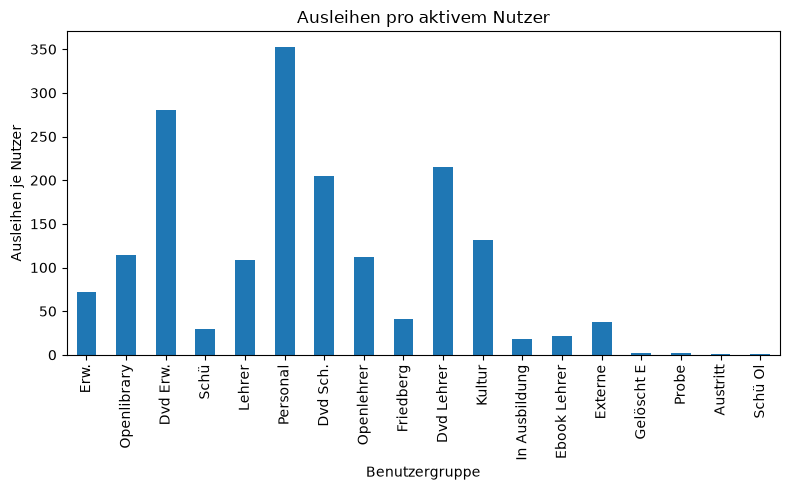

In [80]:
top5 = gruppen_stats.head(20)
import matplotlib.pyplot as plt

top5['Ausleihe_pro_Nutzer'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Ausleihen pro aktivem Nutzer')
plt.ylabel('Ausleihen je Nutzer')
plt.tight_layout()
plt.show()

In [70]:
user_stats = (
    df_clean.groupby(['Ausleihperson', 'Benutzergruppe'])
    .agg(
        Ausleihen=('Ausleihperson', 'size')
    )
    .reset_index()
)

print(user_stats.head(20))

   Ausleihperson Benutzergruppe  Ausleihen
0     1234567890       Austritt          1
1          30006           Erw.          3
2          30006    Openlibrary         55
3          30011           Erw.        106
4          30012           Erw.         18
5          30012    Openlibrary         27
6          30021           Erw.         29
7          30022           Erw.         18
8          30025           Erw.         24
9          30025    Openlibrary        152
10         30037           Erw.         32
11         30041           Erw.          4
12         30041    Openlibrary         19
13         30045           Erw.        117
14         30045    Openlibrary          4
15         30048    Openlibrary         16
16         30054           Erw.        154
17         30055           Erw.         94
18         30068    Openlibrary         27
19         30069           Erw.         25


In [71]:
gueltige_gruppen=['Schü','Schü OL', 'Lehrer', 'DVD Lehrer','DVD Sch.','DVD Erw.' 'Erw', 'Personal','Externe', 'OpenLibrary', 'openLibrary', 'Kultur','ebook Lehrer','in Ausbildung','Friedberg']
user_stats_plot = user_stats[
    user_stats['Benutzergruppe'].isin(gueltige_gruppen)
]

In [72]:
import plotly.io as pio
import plotly.express as px

pio.renderers.default = "browser"

fig = px.scatter(
    user_stats,
    x='Ausleihtage',
    y='Ausleihen',
    color='Benutzergruppe',
    hover_data=['Ausleihperson'],
    opacity=0.6
)

fig.show()

ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of ['Ausleihperson', 'Benutzergruppe', 'Ausleihen'] but received: Ausleihtage

In [75]:
print("=== 🛡️ DATEN-QUALITÄTS-CHECK ===\n")

# 1. Dubletten prüfen (basierend auf eindeutigen Transaktions-Merkmalen)
# Annahme: NR Zugang ist eindeutig pro Transaktion. Wenn nicht, Kombination prüfen.
duplicates = df_clean.duplicated(subset=['NR Zugang', 'Ausleihperson', 'Ausleihdatum'], keep=False)
if duplicates.any():
    print(f"⚠️  ACHTUNG: {duplicates.sum()} potenzielle Dubletten gefunden (gleiche NR, Person, Datum).")
    # Anzeige der ersten Dublette
    #print(df_clean[duplicates].head(10))
else:
    print("✅ Keine Dubletten gefunden.")

# 2. Logische Datums-Fehler
# Fehler A: Rückgabe vor Ausleihe
logic_error_a = df_clean[
    df_clean['Rückgabedatum'].notna() & 
    (df_clean['Rückgabedatum'] < df_clean['Ausleihdatum'])
]
if not logic_error_a.empty:
    print(f"⚠️  ACHTUNG: {len(logic_error_a)} Datensätze mit Rückgabedatum VOR Ausleihdatum!")

# Fehler B: Leihfrist-Ende vor Ausleihe
logic_error_b = df_clean[
    df_clean['Ausleihe bis'].notna() & 
    (df_clean['Ausleihe bis'] < df_clean['Ausleihdatum'])
]
if not logic_error_b.empty:
    print(f"⚠️  ACHTUNG: {len(logic_error_b)} Datensätze mit Leihfrist-Ende VOR Ausleihdatum!")

# Fehler C: Rückgabe in der Zukunft (heute ist 2026-06-16 laut Systemzeit)
# Wir nehmen einen kleinen Puffer von 1 Tag für Zeitzonen/Uhrzeit-Probleme
from datetime import timedelta
today = pd.Timestamp.now()
logic_error_c = df_clean[
    df_clean['Rückgabedatum'].notna() & 
    (df_clean['Rückgabedatum'] > today + timedelta(days=1))
]
if not logic_error_c.empty:
    print(f"⚠️  ACHTUNG: {len(logic_error_c)} Datensätze mit Rückgabedatum in der fernen Zukunft!")

if not any([logic_error_a.empty, logic_error_b.empty, logic_error_c.empty]):
    print("✅ Keine logischen Datumsfehler gefunden.")

# 3. "Verwaiste" aktive Ausleihen (Sehr alt, kein Rückgabedatum)
# Threshold: älter als 3 Jahre
threshold_date = pd.Timestamp.now() - pd.DateOffset(years=3)
old_outstanding = df_clean[
    (df_clean['Rückgabedatum'].isna()) & 
    (df_clean['Ausleihdatum'] < threshold_date)
]
if not old_outstanding.empty:
    print(f"⚠️  ACHTUNG: {len(old_outstanding)} Ausleihen sind seit über 3 Jahren als 'aktiv' markiert (kein Rückgabedatum).")
    # Optional: Top 5 der ältesten anzeigen
    print(old_outstanding.sort_values('Ausleihdatum')[['MedienTitel', 'Ausleihdatum', 'Ausleihperson']].head())
else:
    print("✅ Keine verdächtig alten offenen Ausleihen gefunden.")

# 4. Kategorien-Konsistenz (Leerzeichen & Varianten)
print("\n--- Prüfung auf inkonsistente Kategorien ---")
for col in ['Benutzergruppe', 'Medienart', 'Zweigstelle']:
    if col in df_clean.columns:
        # Anzahl eindeutiger Werte vs. Anzahl Werte nach Strippen und Lowercasing
        unique_raw = df_clean[col].nunique()
        unique_clean = df_clean[col].astype(str).str.strip().str.lower().nunique()
        
        if unique_raw != unique_clean:
            print(f"⚠️  Spalte '{col}': Mögliche Inkonsistenzen durch Leerzeichen/Großschreibung ({unique_raw} vs {unique_clean} bereinigt).")
            # Zeige die Varianten
            print(df_clean[col].value_counts().head(10))
        else:
            print(f"✅ Spalte '{col}': Konsistent.")

# 5. Ausreißer bei Exemplaren
if 'Anz_Exemplare' in df_clean.columns:
    # Konvertieren zu numerisch, falls noch String
    df_clean['Anz_Exemplare_num'] = pd.to_numeric(df_clean['Anz_Exemplare'], errors='coerce')
    outliers = df_clean[df_clean['Anz_Exemplare_num'] > 10] # Mehr als 10 Exemplare pro Transaktion ist selten
    if not outliers.empty:
        print(f"⚠️  ACHTUNG: {len(outliers)} Transaktionen mit mehr als 10 Exemplaren (Ausreißer?).")
    else:
        print("✅ Keine extremen Mengen-Ausreißer gefunden.")

print("\n=== Ende Qualitätscheck ===")

=== 🛡️ DATEN-QUALITÄTS-CHECK ===

⚠️  ACHTUNG: 429 potenzielle Dubletten gefunden (gleiche NR, Person, Datum).
⚠️  ACHTUNG: 388 Datensätze mit Rückgabedatum VOR Ausleihdatum!
✅ Keine verdächtig alten offenen Ausleihen gefunden.

--- Prüfung auf inkonsistente Kategorien ---
✅ Spalte 'Benutzergruppe': Konsistent.
✅ Spalte 'Medienart': Konsistent.
✅ Spalte 'Zweigstelle': Konsistent.
✅ Keine extremen Mengen-Ausreißer gefunden.

=== Ende Qualitätscheck ===


In [76]:
import pandas as pd
import numpy as np

# Annahme: df_clean ist dein bereinigter DataFrame mit konvertierten Datumsfeldern

# 1. Identifiziere die "Fehler-Fälle" (Rückgabe vor Ausleihe)
mask_datum_fehler = (
    df_clean['Rückgabedatum'].notna() & 
    (df_clean['Rückgabedatum'] < df_clean['Ausleihdatum'])
)

fehler_df = df_clean[mask_datum_fehler].copy()

print(f"Anzahl Datensätze mit Rückgabedatum < Ausleihdatum: {len(fehler_df)}")

if not fehler_df.empty:
    print("\n--- Analyse der ersten 5 Fälle ---")
    # Zeige die relevanten Felder an, um das Muster zu erkennen
    cols = ['MedienTitel', 'Ausleihdatum', 'Ausleihe bis', 'Rückgabedatum', 'Verlängerung_Anz', 'Transaktionstyp(1)']
    cols = [c for c in cols if c in fehler_df.columns]
    print(fehler_df[cols].head())

    # 2. Hypothesen-Check: Sind es Verlängerungen?
    # Wenn 'Verlängerung_Anz' nicht leer ist, ist es offiziell eine Verlängerung.
    # Oder wenn Transaktionstyp(1) == 1 (was oft für Ausleihe/Verlängerung steht)
    
    # Prüfen ob Feld 'Verlängerung_Anz' existiert und Werte hat
    if 'Verlängerung_Anz' in fehler_df.columns:
        # Leere Strings oder NaN als 0 behandeln für den Check
        verlängerungen = fehler_df[fehler_df['Verlängerung_Anz'].astype(str).str.strip() != '']
        print(f"\nDavon sind {len(verlängerungen)} explizit als Verlängerung markiert ('Verlängerung_Anz' ist gesetzt).")
        
        # Wenn die Mehrheit Verlängerungen sind, ist es kein "Fehler", sondern Systemlogik.
        if len(verlängerungen) > len(fehler_df) * 0.5:
            print("\n✅ ERGEBNIS: Die meisten 'Fehler' sind tatsächlich Verlängerungs-Datensätze.")
            print("   Empfehlung: Diese Datensätze NICHT löschen. Sie repräsentieren eine neue Leihperiode.")
            print("   Für die Statistik 'Anzahl Ausleihen' sollten sie mitgezählt werden.")
            print("   Für die Statistik 'Ausleihdauer' ist die negative Dauer hier aber problematisch.")
            
            # STRATEGIE: 
            # Wir korrigieren das Rückgabedatum für die Dauer-Berechnung auf das Ausleihdatum (Dauer = 0)
            # ODER wir ignorieren diese Fälle bei der Durchschnittsberechnung.
            # Hier setzen wir es auf das Ausleihdatum, damit es den Durchschnitt nicht nach unten zieht.
            df_clean.loc[mask_datum_fehler, 'Rückgabedatum_korrigiert'] = df_clean.loc[mask_datum_fehler, 'Ausleihdatum']
            
        else:
            print("\n⚠️  Nur einige sind Verlängerungen. Andere könnten echte Datenerfassungsfehler sein.")
            df_clean.loc[mask_datum_fehler, 'Rückgabedatum_korrigiert'] = pd.NaT # Als unbekannt markieren
    else:
        print("Kein Feld 'Verlängerung_Anz' gefunden. Manuelle Prüfung der obigen Tabelle nötig.")
        df_clean.loc[mask_datum_fehler, 'Rückgabedatum_korrigiert'] = pd.NaT

else:
    print("Keine Datums-Inkonsistenzen gefunden.")
    df_clean['Rückgabedatum_korrigiert'] = df_clean['Rückgabedatum']

# Sicherstellen, dass alle anderen ein korrektes Rückgabedatum haben
if 'Rückgabedatum_korrigiert' not in df_clean.columns:
    df_clean['Rückgabedatum_korrigiert'] = df_clean['Rückgabedatum']
else:
    # Fülle die Fälle, die KEINE Fehler waren, mit dem originalen Datum
    mask_ok = ~mask_datum_fehler
    df_clean.loc[mask_ok, 'Rückgabedatum_korrigiert'] = df_clean.loc[mask_ok, 'Rückgabedatum']

print("\n✅ Spalte 'Rückgabedatum_korrigiert' ist bereit für die Berechnung der Ausleihdauer.")

Anzahl Datensätze mit Rückgabedatum < Ausleihdatum: 388

--- Analyse der ersten 5 Fälle ---
                               MedienTitel Ausleihdatum Ausleihe bis  \
677                          Back mit mir!   2024-06-20   2024-08-27   
678                                  Elmar   2024-06-20   2024-08-27   
981              Ein Sonnenstrahl im Regen   2024-06-22   2024-08-27   
982          Verliebt bis über alle Sterne   2024-06-22   2024-08-27   
983  Gott hat auch mal 'nen schlechten Tag   2024-06-22   2024-08-27   

    Rückgabedatum Verlängerung_Anz Transaktionstyp(1)  
677    2024-06-11                1                  1  
678    2024-06-11                1                  1  
981    2024-06-13                1                  1  
982    2024-06-13                1                  1  
983    2024-06-13                1                  1  

Davon sind 388 explizit als Verlängerung markiert ('Verlängerung_Anz' ist gesetzt).

✅ ERGEBNIS: Die meisten 'Fehler' sind tatsächlich Ver